In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [81]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [82]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [89]:
num_cols = [
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3-Q1

LB = Q1 - (1.5*IQR)
UB = Q3 + (1.5*IQR)

outliers_detected = (df[num_cols] < LB) | (df[num_cols] > UB)

outlier_count = outliers_detected.sum()

iqr_summary = pd.DataFrame({
    'Q1' : Q1,
    'Q3' : Q3,
    'LB' : LB,
    'UB' : UB,
    'Outlier count' : outlier_count
})
iqr_summary

# Calculate Z-Scores
z_scores = df[num_cols].apply(zscore)

# Detect Outliers
outliers_detected = abs(z_scores) > 3

# Count Outliers
outlier_count = outliers_detected.sum()

# Create Summary Table
zscore_summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Std Dev': df[num_cols].std(),
    'Outlier Count': outlier_count
})

print(zscore_summary)


            Mean    Std Dev  Outlier Count
Age    29.699118  14.526497              0
SibSp   0.523008   1.102743             30
Parch   0.381594   0.806057             15
Fare   32.204208  49.693429             20


In [84]:
print("Mean\n", df.mean(numeric_only=True))
print(df.median(numeric_only=True))

Mean
 PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64


<Axes: ylabel='Age'>

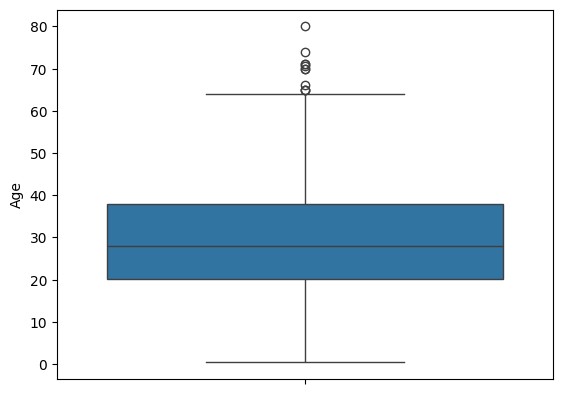

In [85]:
import seaborn as sns
sns.boxplot(y=df['Age'])

In [86]:
df[['Age','Fare']]

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [87]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


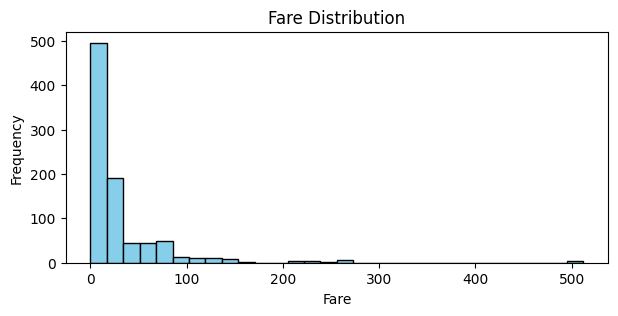

In [88]:
plt.figure(figsize=(7,3))

plt.hist(
    df['Fare'].dropna(),
    bins=30,
    color='skyblue',
    edgecolor='black'
)

plt.title("Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.show()